In [1]:
import ee
import pandas as pd
import numpy as np
import folium
from folium import plugins
!pip install rasterio
!pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 49.8 MB/s eta 0:00:00


In [2]:
from folium import plugins
import math

In [3]:
# 1) Autenticación / inicialización (te pedirá abrir un link la primera vez)

ee.Authenticate()
ee.Initialize(project='my-project-470519')


In [4]:
# 2) DEM y productos de terreno (FIX para GLO-30 que es ImageCollection)
dem_ic = ee.ImageCollection("COPERNICUS/DEM/GLO30").select("DEM")
DEM = dem_ic.mosaic().rename("elevation")   # ahora es una Image con banda 'elevation'
TERRAIN = ee.Terrain.products(DEM)          # slope, aspect, hillshade a partir de 'elevation'
SCALE = 30


# 3) Coordenadas hardcodeadas (ejemplo: llena tus coords exactas)
#    reemplaza lat/lon por los reales
stations = [
    {"nombre": "Noreste3 Pesqueria",     "clave": "Pesqueria",     "lat": 25.791343, "lon": -100.078176},
    {"nombre": "Norte2 Universidad",     "clave": "Universidad",   "lat": 25.729787, "lon": -100.310028},
    {"nombre": "Noroeste San Bernabé",   "clave": "San Bernabé",   "lat": 25.757120, "lon": -100.365974},
    {"nombre": "Noroeste 2 Garcia",      "clave": "Garcia",        "lat": 25.783331, "lon": -100.585833},
    {"nombre": "Centro Obispado",        "clave": "Obispado",      "lat": 25.676020, "lon": -100.335847},
    {"nombre": "Sureste3 Cadereyta",     "clave": "Cadereyta",     "lat": 25.600870, "lon":  -99.995334},
    {"nombre": "Suroeste2 San Pedro",    "clave": "San Pedro",     "lat": 25.665280, "lon": -100.412778},
    {"nombre": "Sur Preparatoria ITESM", "clave": "Preparatoria ITESM", "lat": 25.575383, "lon": -100.249371},
    {"nombre": "Noreste San Nicolas",    "clave": "San Nicolas",   "lat": 25.745430, "lon": -100.255020},
    {"nombre": "Noroeste 3 Garcia",      "clave": "Mision San Juan","lat": 25.785307, "lon": -100.463958},
    {"nombre": "Sureste 2 Juarez",       "clave": "Juarez",        "lat": 25.646110, "lon": -100.095555},
    {"nombre": "Suroeste Santa Catarina","clave": "Santa Catarina","lat": 25.675356, "lon": -100.460037},
    {"nombre": "Norte Escobedo",         "clave": "Escobedo",      "lat": 25.801940, "lon": -100.343056},
    {"nombre": "Noreste 2 Apodaca",      "clave": "Apodaca",       "lat": 25.777220, "lon": -100.188055},
    {"nombre": "Sureste Tec NL",         "clave": "Tec de Nuevo León", "lat": 25.668270, "lon": -100.249580},
]

In [5]:
m = folium.Map(location=[25.67, -100.31], zoom_start=10, tiles="CartoDB positron")

# Agregar marcadores y círculos de 2km
for s in stations:
    # Crear marcador
    folium.Marker(
        location=[s["lat"], s["lon"]],
        popup=f"{s['nombre']}<br>Clave: {s['clave']}<br>Lat/Lon: {s['lat']}, {s['lon']}",
        tooltip=s["nombre"],
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(m)

    # Agregar círculo de 2km (2000 metros) alrededor de la estación
    folium.Circle(
        location=[s["lat"], s["lon"]],
        radius=6000,  # Radio en metros
        popup=f"Radio de 2km alrededor de {s['nombre']}",
        color="blue",
        fill=True,
        fillColor="blue",
        fillOpacity=0.2,
        weight=1
    ).add_to(m)

# Añadir control de capas para poder activar/desactivar los círculos
folium.LayerControl().add_to(m)

# Mostrar el mapa
m

In [6]:
# 4) Helper para calcular métricas en un buffer
def topo_stats_for_point(lat, lon, buffer_m=250):
    pt = ee.Geometry.Point([lon, lat])
    roi = pt.buffer(buffer_m)  # círculo en metros (geodesic)

    # Elevación (mean/std)
    elev_mean = DEM.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=roi, scale=SCALE, maxPixels=1e9
    ).get("elevation")
    elev_std  = DEM.reduceRegion(
        reducer=ee.Reducer.stdDev(), geometry=roi, scale=SCALE, maxPixels=1e9
    ).get("elevation")

    # Pendiente / Aspecto (mean)
    slope_mean  = TERRAIN.select("slope").reduceRegion(
        reducer=ee.Reducer.mean(), geometry=roi, scale=SCALE, maxPixels=1e9
    ).get("slope")
    aspect_mean = TERRAIN.select("aspect").reduceRegion(
        reducer=ee.Reducer.mean(), geometry=roi, scale=SCALE, maxPixels=1e9
    ).get("aspect")

    # Recolectar resultados (getInfo porque el N es pequeño)
    out = ee.Dictionary({
        "elev_mean": elev_mean,
        "elev_std" : elev_std,
        "slope_mean_deg": slope_mean,
        "aspect_mean_deg": aspect_mean
    }).getInfo()

    # Derivar sin/cos del aspecto (0° = Norte en GEE)
    if out.get("aspect_mean_deg") is not None:
        ang = np.deg2rad(out["aspect_mean_deg"])
        out["aspect_sin"] = float(np.sin(ang))
        out["aspect_cos"] = float(np.cos(ang))
    else:
        out["aspect_sin"] = None
        out["aspect_cos"] = None

    return out

# 5) Loop estaciones con dos buffers (250 m y 1000 m)
rows = []
for s in stations:
    base = {"nombre": s["nombre"], "clave": s["clave"], "lat": s["lat"], "lon": s["lon"]}

    # 250 m
    st250 = topo_stats_for_point(s["lat"], s["lon"], buffer_m=250)
    for k, v in st250.items():
        base[f"{k}_250m"] = v

    # 1000 m
    st1000 = topo_stats_for_point(s["lat"], s["lon"], buffer_m=1000)
    for k, v in st1000.items():
        base[f"{k}_1000m"] = v

    rows.append(base)

# 6) DataFrame y export
df_topo = pd.DataFrame(rows)

cols_order = [
    "nombre","clave","lat","lon",
    "elev_mean_250m","elev_std_250m","slope_mean_deg_250m","aspect_mean_deg_250m","aspect_sin_250m","aspect_cos_250m",
    "elev_mean_1000m","elev_std_1000m","slope_mean_deg_1000m","aspect_mean_deg_1000m","aspect_sin_1000m","aspect_cos_1000m"
]
# Reordenar si todas existen (si no, deja tal cual)
df_topo = df_topo[[c for c in cols_order if c in df_topo.columns]]

df_topo.to_csv("topografia_estaciones.csv", index=False)
print("Guardado: topografia_estaciones.csv")
print(df_topo.head())

Guardado: topografia_estaciones.csv
                 nombre        clave        lat         lon  elev_mean_250m  \
0    Noreste3 Pesqueria    Pesqueria  25.791343 -100.078176      347.496541   
1    Norte2 Universidad  Universidad  25.729787 -100.310028      517.400024   
2  Noroeste San Bernabé  San Bernabé  25.757120 -100.365974      553.386250   
3     Noroeste 2 Garcia       Garcia  25.783331 -100.585833      713.744585   
4       Centro Obispado     Obispado  25.676020 -100.335847      552.332005   

   elev_std_250m  slope_mean_deg_250m  aspect_mean_deg_250m  aspect_sin_250m  \
0       3.324017                    0                    45         0.707107   
1       2.813526                    0                    45         0.707107   
2       2.233029                    0                    45         0.707107   
3       3.730520                    0                    45         0.707107   
4       1.693243                    0                    45         0.707107   

   aspec

In [7]:
import ee, requests, os, io, numpy as np, matplotlib.pyplot as plt, rasterio
from shapely.geometry import Point, mapping
import geopandas as gpd

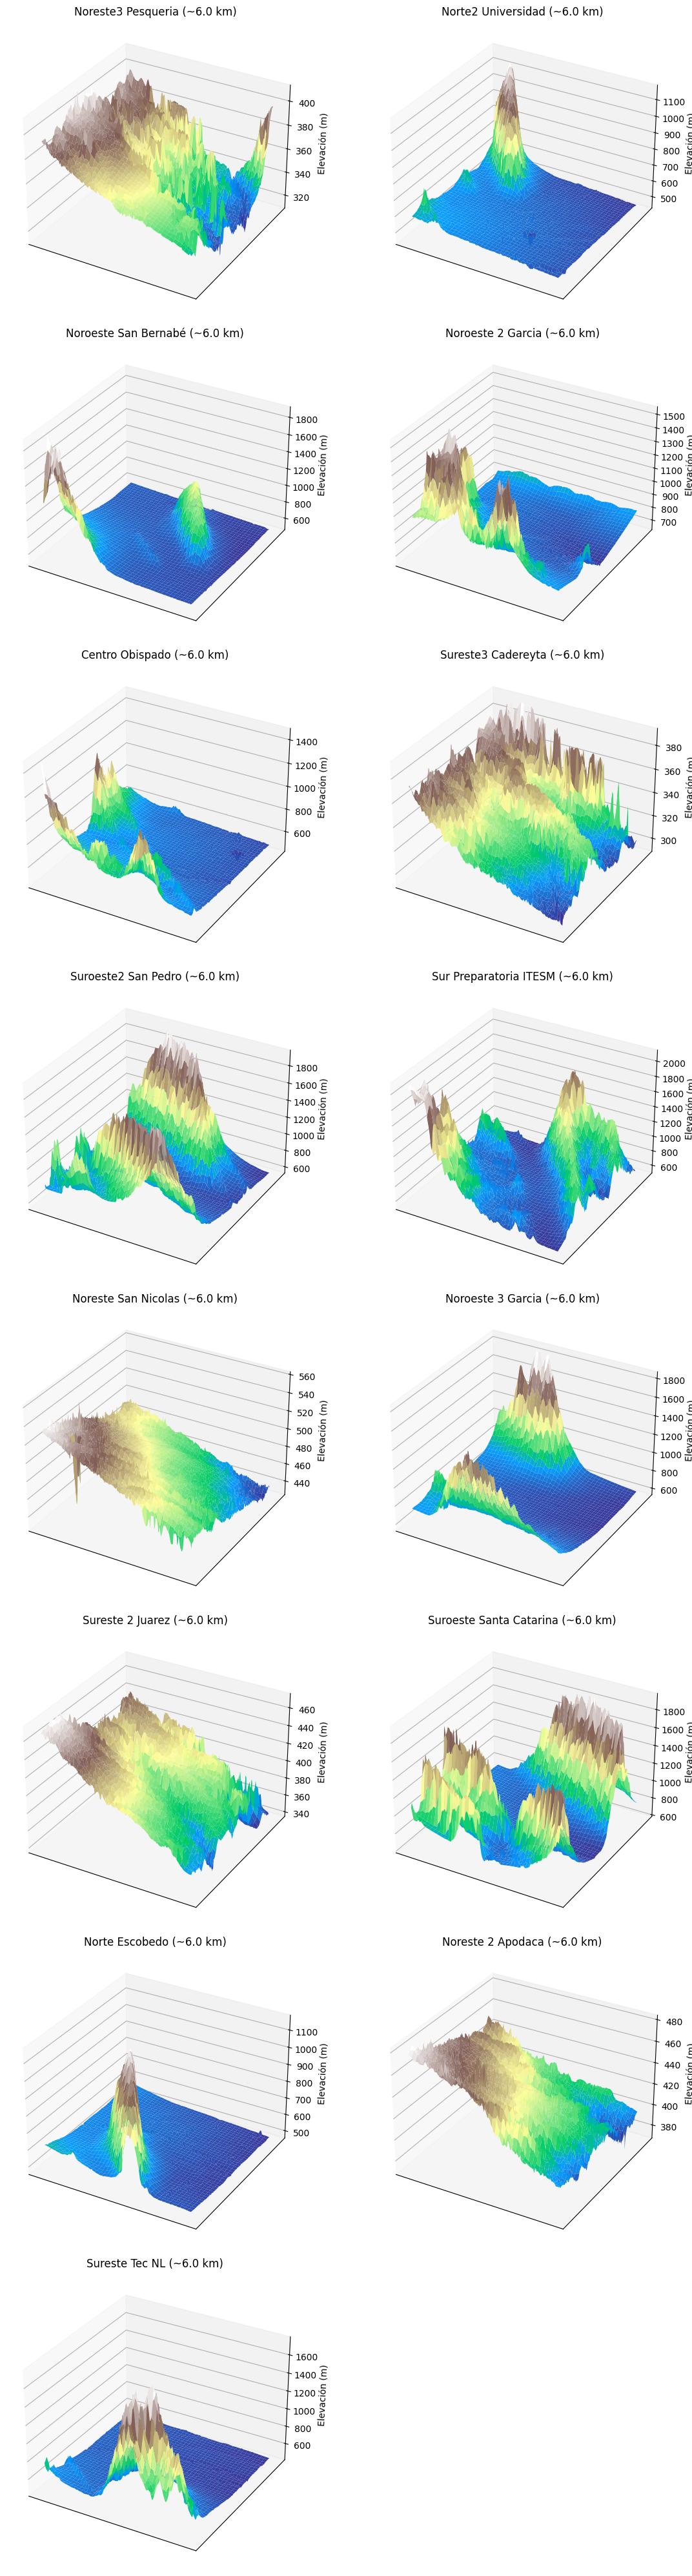

In [8]:
# 4) Parámetros
RADIUS_M = 6000       # radio del parche (2 km)
PIXEL_M  = 30         # resolución objetivo p/ reproject (opcional)
OUTDIR   = "DEM3D_png"
os.makedirs(OUTDIR, exist_ok=True)

# Proyección opcional a ~30 m (ayuda a controlar el tamaño del array)
proj = DEM.projection().atScale(PIXEL_M)
DEM30 = DEM.reproject(proj)

# Kernel cuadrado de RADIUS_M (en metros)
kernel = ee.Kernel.square(radius=RADIUS_M, units='meters', normalize=False)

# Imagen de arreglos (cada píxel contiene un array 2D de elevaciones del vecindario)
ARR = DEM30.neighborhoodToArray(kernel)  # banda se llamará 'elevation'

def fetch_patch_array(lat, lon):
    """Devuelve matriz Z (2D) de elevaciones alrededor del punto (lat, lon)."""
    pt = ee.Geometry.Point([lon, lat])

    # Tomar UNA muestra en el punto: trae un Feature con propiedad 'elevation' = array
    feat = ARR.sample(region=pt, scale=PIXEL_M, numPixels=1, tileScale=1).first()
    if feat is None:
        return None

    # Extraer el array como lista de listas
    arr = feat.get('elevation').getInfo()
    if arr is None:
        return None

    Z = np.array(arr, dtype='float32')
    # neighborhoodToArray devuelve (filas, columnas). Si es 1D, descartar.
    if Z.ndim != 2 or Z.size == 0:
        return None
    return Z

# --- Mostrar 3D en pantalla, 2 por fila ---
def show_surface_grid(stations, RADIUS_M=2000, PIXEL_M=30, max_dim=220):
    n = len(stations)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig = plt.figure(figsize=(12, 5 * nrows))

    for i, s in enumerate(stations, 1):
        try:
            Z = fetch_patch_array(s["lat"], s["lon"])
            if Z is None:
                print(f"⚠ Parche vacío — {s['nombre']}")
                continue

            # Submuestreo
            sr = max(1, int(np.ceil(Z.shape[0] / max_dim)))
            sc = max(1, int(np.ceil(Z.shape[1] / max_dim)))

            Y, X = np.mgrid[0:Z.shape[0], 0:Z.shape[1]]

            ax = fig.add_subplot(nrows, ncols, i, projection="3d")
            ax.plot_surface(
                X[::sr, ::sc], Y[::sr, ::sc], Z[::sr, ::sc],
                cmap="terrain", linewidth=0, antialiased=True, alpha=0.97
            )
            ax.set_title(f"{s['nombre']} (~{RADIUS_M/1000:.1f} km)")
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_zlabel("Elevación (m)")

        except Exception as e:
            print(f"Error con {s['nombre']}: {e}")

    plt.tight_layout()
    plt.show()

# --- Ejecutar ---
show_surface_grid(stations, RADIUS_M=6000, PIXEL_M=30)

In [9]:
import numpy as np
import pandas as pd
import math

# --- métricas topográficas ---
def dem_metrics(Z, pixel_m=30):
    """
    Z: matriz 2D de elevaciones (float), con posible NaN
    pixel_m: tamaño de celda (m)
    """
    Z = np.array(Z, dtype=float)
    # enmascara NaN para gradiente
    mask = np.isfinite(Z)
    if mask.sum() < 9:  # muy pocos válidos
        return None

    # Rellena pequeños huecos internos con el valor vecino (opcional)
    Z_f = Z.copy()
    if np.isnan(Z_f).any():
        # simple fill: usa mediana global para NaN extremos (rápido)
        Z_f[np.isnan(Z_f)] = np.nanmedian(Z_f)

    # Gradientes (m/m)
    gy, gx = np.gradient(Z_f, pixel_m, pixel_m)
    slope_rad = np.arctan(np.hypot(gx, gy))     # pendiente en radianes
    slope_deg = np.degrees(slope_rad)           # a grados

    # Métricas
    mean_slope = float(np.nanmean(slope_deg))
    std_elev   = float(np.nanstd(Z))
    relief     = float(np.nanmax(Z) - np.nanmin(Z))

    # Señal de "valle": centro vs borde
    r0, c0 = Z.shape[0]//2, Z.shape[1]//2
    z_center = float(Z[r0, c0]) if np.isfinite(Z[r0, c0]) else float(np.nanmedian(Z))
    border = np.concatenate([Z[0, :], Z[-1, :], Z[:, 0], Z[:, -1]])
    z_border_med = float(np.nanmedian(border))
    delta_border_center = z_border_med - z_center  # >0: centro más bajo (tendencia a valle)

    return {
        "mean_slope_deg": mean_slope,
        "std_elev_m": std_elev,
        "relief_m": relief,
        "delta_border_center_m": delta_border_center,
        "z_center_m": z_center,
        "z_border_med_m": z_border_med,
        "n_rows": Z.shape[0],
        "n_cols": Z.shape[1],
    }

# --- reglas de clasificación (puedes ajustar umbrales a tu criterio) ---
def classify_site(m):
    """
    m: dict de métricas devuelto por dem_metrics
    """
    if m is None:
        return "sin_datos"

    relief = m["relief_m"]
    slope  = m["mean_slope_deg"]
    delta  = m["delta_border_center_m"]

    # 1) Planicie: poco relieve y pendiente suave
    if relief < 80 and slope < 3:
        return "planicie"

    # 2) Valle: centro claramente más bajo que bordes y relieve suficiente
    if delta > 50 and relief >= 120:
        return "valle"

    # 3) Ladera (resto): relieve/pediente moderados o altos
    return "ladera"

# --- ejecutar para todas las estaciones ---
rows = []
for s in stations:
    Z = fetch_patch_array(s["lat"], s["lon"])  # DEM local ya preparado
    if Z is None:
        rows.append({"estacion": s["nombre"], "clasificacion": "sin_datos"})
        continue
    m = dem_metrics(Z, pixel_m=PIXEL_M)
    cls = classify_site(m)
    rows.append({
        "estacion": s["nombre"],
        "clasificacion": cls,
        **(m if m else {})
    })

df_topo = pd.DataFrame(rows).sort_values("estacion")
df_topo


,estacion,clasificacion,mean_slope_deg,std_elev_m,relief_m,delta_border_center_m,z_center_m,z_border_med_m,n_rows,n_cols
4,Centro Obispado,valle,6.240741,107.183554,1034.016785,50.289398,550.611206,600.900604,401,401
13,Noreste 2 Apodaca,ladera,1.887058,21.958962,114.869720,-11.060974,431.072968,420.011993,401,401
8,Noreste San Nicolas,ladera,1.833354,21.964814,135.025604,-0.869507,474.121826,473.252319,401,401
0,Noreste3 Pesqueria,ladera,1.878918,20.574588,100.181976,16.348511,349.099426,365.447937,401,401
3,Noroeste 2 Garcia,valle,7.546479,166.148974,894.670654,89.216766,713.923767,803.140533,401,401
9,Noroeste 3 Garcia,valle,7.245879,187.024289,1288.811523,137.992676,606.412170,744.404846,401,401
2,Noroeste San Bernabé,ladera,6.811937,184.032922,1406.533630,-2.009338,554.318176,552.308838,401,401
12,Norte Escobedo,ladera,4.199571,112.229886,703.081940,0.363251,520.446899,520.810150,401,401
1,Norte2 Universidad,ladera,4.147595,103.806398,729.763977,4.958405,516.223206,521.181610,401,401
7,Sur Preparatoria ITESM,valle,19.432494,281.054272,1586.181885,143.567444,614.254639,757.822083,401,401


# Regresión

In [10]:
import re
import numpy as np
import pandas as pd
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

/usr/local/lib/python3.12/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:19: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [11]:
df_final = pd.read_excel("datos_final.xlsx")

In [12]:
df_final.columns

Index(['date', 'noroeste3_NO', 'noroeste3_NO2', 'noroeste3_NOX',
       'noroeste3_O3', 'noroeste3_PM10', 'noroeste3_PRS', 'noroeste3_RAINF',
       'noroeste3_RH', 'noroeste3_SO2',
       ...
       'sureste_U', 'sureste_V', 'sureste2_U', 'sureste2_V', 'sureste3_U',
       'sureste3_V', 'suroeste_U', 'suroeste_V', 'suroeste2_U', 'suroeste2_V'],
      dtype='object', length=224)

In [13]:
#@title #1) Imports + carga de datos (datos_final.xlsx y topografia_estaciones.csv)
import os, re, unicodedata, math, warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.spatial import procrustes
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

DATA_XLSX = "datos_final.xlsx"
TOPO_CSV  = "topografia_estaciones.csv"
assert os.path.exists(DATA_XLSX), f"No se encuentra {DATA_XLSX}"
assert os.path.exists(TOPO_CSV),  f"No se encuentra {TOPO_CSV}"

df_final = pd.read_excel(DATA_XLSX)
print("✔ df_final:", df_final.shape)
topo_raw = pd.read_csv(TOPO_CSV)
print("✔ topo_raw:", topo_raw.shape)


✔ df_final: (13870, 224)
✔ topo_raw: (15, 16)


In [14]:
#@title #2) Utilidades (timestamp, estaciones, parser wide→tidy)
ORIENTS = r"(CENTRO|NORESTE|NOROESTE|SURESTE|SUROESTE|NORTE|SUR)"

VAR_ALIAS = {
    "PM25":"PM2.5", "PM2_5":"PM2.5",
    "WDR":"WDV", "WIND_DIR":"WDV", "WDIR":"WDV",
    "TEMP":"TOUT","TEMPERATURA":"TOUT",
    "HUM":"RH","HUMEDAD":"RH",
    "PRES":"PRS","PRESION":"PRS",
    "SOLAR":"SR","RAD":"SR"
}

def strip_accents(s: str) -> str:
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")

def normalize_station_key(name: str) -> str:
    if not isinstance(name, str):
        name = str(name)
    s = strip_accents(name).upper()
    s = s.replace("_", " ")
    s = re.sub(r"\s+", " ", s).strip()
    m = re.search(rf"{ORIENTS}\s*(\d+)?", s, flags=re.I)
    if m:
        orient = m.group(1).upper()
        num = m.group(2) or ""
        return (orient + (" " + num if num else "")).strip()
    m2 = re.search(rf"{ORIENTS}", s, flags=re.I)
    if m2:
        return m2.group(1).upper()
    return s

def detect_time_column(df: pd.DataFrame):
    candidates = list(df.columns)
    best_col, best_hits = None, -1
    for c in candidates:
        try:
            t = pd.to_datetime(df[c], errors="coerce")
            hits = t.notna().sum()
            if hits > best_hits and hits > 0:
                best_hits = hits; best_col = c
        except Exception:
            pass
    assert best_col is not None, "No pude detectar columna de tiempo."
    return best_col

def parse_col_station_var(colname: str):
    """
    Espera columnas tipo '<ESTACIÓN>_<IDX>_<VAR>' o '<ESTACIÓN>_<VAR>'.
    Devuelve (station_key, var).
    """
    s = str(colname)
    parts = s.split("_")
    if len(parts) >= 3:
        var_raw = parts[-1].strip()
        station_raw = "_".join(parts[:-2]).strip()
    elif len(parts) == 2:
        station_raw, var_raw = parts[0].strip(), parts[1].strip()
    else:
        return None, None
    var = VAR_ALIAS.get(var_raw.upper(), var_raw.upper())
    st_key = normalize_station_key(station_raw)
    return st_key, var

def to_tidy(df_wide: pd.DataFrame, time_col: str):
    recs = []
    for c in df_wide.columns:
        if c == time_col:
            continue
        st, var = parse_col_station_var(c)
        if st and var:
            tmp = df_wide[[time_col, c]].copy()
            tmp.columns = ["timestamp","valor"]
            tmp["estacion"] = st
            tmp["variable"] = var
            recs.append(tmp)
    long = pd.concat(recs, axis=0, ignore_index=True)
    tidy = (long.pivot_table(index=["timestamp","estacion"],
                             columns="variable", values="valor", aggfunc="first")
                  .reset_index())
    tidy.columns.name = None
    tidy["timestamp"] = pd.to_datetime(tidy["timestamp"], errors="coerce")
    return tidy

time_col = detect_time_column(df_final)
tidy = to_tidy(df_final, time_col=time_col)
print("✔ tidy:", tidy.shape, " | columnas:", len(tidy.columns))
print("Vars ejemplo:", [c for c in tidy.columns if c not in ["timestamp","estacion"]][:15])


✔ tidy: (189664, 17)  | columnas: 17
Vars ejemplo: ['NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS', 'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'U', 'V', 'WDV']


In [15]:
#@title #3) Features + objetivos (PM25_12h, O3_8h_ppm) — sin imputar
tidy = tidy.sort_values(["estacion","timestamp"]).copy()
tidy["anio"] = tidy["timestamp"].dt.year
tidy["mes"]  = tidy["timestamp"].dt.month
tidy["hora"] = tidy["timestamp"].dt.hour

# Dirección del viento → seno/coseno (si existe WDV en grados)
if "WDV" in tidy.columns:
    rad = np.deg2rad(pd.to_numeric(tidy["WDV"], errors="coerce"))
    tidy["WDV_sin"] = np.sin(rad)
    tidy["WDV_cos"] = np.cos(rad)

# O3 a ppm (si viene en ppb)
if "O3_ppm" not in tidy.columns and "O3" in tidy.columns:
    tidy["O3_ppm"] = pd.to_numeric(tidy["O3"], errors="coerce") / 1000.0

def trailing_mean_by_estacion_anio(df, value_col, out_col, window_h, min_frac=0.75):
    df = df.copy()
    df[out_col] = np.nan
    w = int(window_h)
    minp = int(math.ceil(w * float(min_frac)))
    for (est, yr), sub in df.groupby(["estacion","anio"], sort=False):
        s = pd.to_numeric(sub[value_col], errors="coerce")
        roll = s.rolling(window=w, min_periods=minp).mean()
        df.loc[sub.index, out_col] = roll.values
    return df

if "PM2.5" in tidy.columns:
    tidy = trailing_mean_by_estacion_anio(tidy, "PM2.5",   "PM25_12h", 12, min_frac=0.75)
if "O3_ppm" in tidy.columns:
    tidy = trailing_mean_by_estacion_anio(tidy, "O3_ppm",  "O3_8h_ppm", 8,  min_frac=0.75)

print("PM25_12h NaN%:", tidy["PM25_12h"].isna().mean() if "PM25_12h" in tidy.columns else "NA")
print("O3_8h_ppm NaN%:", tidy["O3_8h_ppm"].isna().mean() if "O3_8h_ppm" in tidy.columns else "NA")


PM25_12h NaN%: 0.12307554412012822
O3_8h_ppm NaN%: 0.0007908722793993589


In [16]:
#@title #4) Unión con topografía
topo = topo_raw.copy()
# intenta detectar columna de nombre de estación
col_est_topo = None
for cand in ["nombre","nombre_estacion","estacion","ESTACION","Nombre","Clave","clave","CLAVE"]:
    if cand in topo.columns:
        col_est_topo = cand; break
assert col_est_topo is not None, "No pude detectar columna de estación en topografía."

topo["estacion"] = topo[col_est_topo].apply(normalize_station_key)
# mantener solo una fila por estación
topo = topo.drop_duplicates("estacion").copy()

# merge (left) para no perder registros de tidy
tidy_m = tidy.merge(topo, on="estacion", how="left")

# chequeo
topo_cols = [c for c in topo.columns if c not in [col_est_topo,"estacion"]]
print("✔ estaciones en tidy:", tidy_m["estacion"].nunique(),
      "| topo unidas:", tidy_m[topo_cols].notna().all(axis=1).mean())
print("Topografía columnas:", topo_cols[:12], "...")


✔ estaciones en tidy: 15 | topo unidas: 1.0
Topografía columnas: ['clave', 'lat', 'lon', 'elev_mean_250m', 'elev_std_250m', 'slope_mean_deg_250m', 'aspect_mean_deg_250m', 'aspect_sin_250m', 'aspect_cos_250m', 'elev_mean_1000m', 'elev_std_1000m', 'slope_mean_deg_1000m'] ...


In [17]:
#@title #5) PCA por estación — robusto a NaN (+ Procrustes, control negativo, block-scaling)

# 5.1) Construir tabla por estación (percentiles) para PCA
cand_vars_meteo = ["PM10","PM2.5","O3","NO","NO2","NOX","SO2","CO","WSR","TOUT","RH","SR"]
present = [v for v in cand_vars_meteo if v in tidy_m.columns]

grp = tidy_m.groupby("estacion")[present]
p50 = grp.quantile(0.50).add_suffix("_P50")
p90 = grp.quantile(0.90).add_suffix("_P90")
tab_meteo_raw = pd.concat([p50, p90], axis=1)

# Topografía depurada (elige subconjunto robusto que exista en tu CSV)
topo_keep = [c for c in [
    "elev_mean_1000m","elev_std_1000m","slope_mean_deg_1000m",
    "aspect_sin_1000m","aspect_cos_1000m",
    "elev_mean_250m","elev_std_250m","slope_mean_deg_250m"
] if c in tidy_m.columns]
tab_topo_raw = tidy_m.groupby("estacion")[topo_keep].first()

# 5.2) Limpieza de la matriz para PCA (solo a nivel estación)
def clean_for_pca(df_station, max_nan_col=0.20):
    """Quita columnas con >max_nan_col NaN y rellena el resto con la mediana por columna.
       También remueve columnas constantes."""
    df = df_station.copy()
    nan_ratio = df.isna().mean().sort_values(ascending=False)
    # Log rápido para diagnóstico
    print("\nTop columnas con mayor %NaN (antes de limpiar):")
    print(nan_ratio.head(8))
    # 1) quita columnas con demasiados NaN entre estaciones
    keep_cols = nan_ratio.index[nan_ratio <= max_nan_col].tolist()
    df = df[keep_cols]
    # 2) imputa NaN restantes con mediana por columna (entre estaciones)
    df = df.apply(lambda s: s.fillna(s.median()), axis=0)
    # 3) elimina columnas constantes
    nun = df.nunique()
    df = df.loc[:, nun[nun > 1].index]
    return df

tab_meteo = clean_for_pca(tab_meteo_raw, max_nan_col=0.20)
tab_topo  = tab_topo_raw.copy()
# Si hubiese algún NaN en topo (no debería), median-fill
if tab_topo.isna().any().any():
    tab_topo = tab_topo.apply(lambda s: s.fillna(s.median()), axis=0)
# Quita constantes (por seguridad)
tab_topo = tab_topo.loc[:, tab_topo.nunique() > 1]

# 5.3) Alinear estaciones (filas) comunes en ambos escenarios
stations_common = tab_meteo.index.intersection(tab_topo.index)
# Para comparar SIN vs CON topo de forma justa usamos el mismo conjunto de estaciones
tab_meteo_aligned = tab_meteo.loc[stations_common].copy()
tab_con_aligned   = tab_meteo_aligned.join(tab_topo.loc[stations_common], how="inner")

print(f"\nEstaciones en PCA (comunes): {len(stations_common)}")
print(f"Cols meteo (P50/P90) usadas: {tab_meteo_aligned.shape[1]}")
print(f"Cols topo usadas: {tab_topo.shape[1]}")

# 5.4) Helpers de PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def run_pca(df_matrix, ncomp=4, title="PCA"):
    X = df_matrix.copy()
    scaler = StandardScaler().fit(X.values)
    Xs = scaler.transform(X.values)
    pca = PCA(n_components=ncomp, random_state=42).fit(Xs)
    loads = pd.DataFrame(pca.components_.T, index=X.columns,
                         columns=[f"PC{i+1}" for i in range(ncomp)])
    print(f"{title} — Varianza explicada:", np.round(pca.explained_variance_ratio_, 3))
    return pca, scaler, loads

def print_top_loads(loads, k=10, label=""):
    for i in range(min(4, loads.shape[1])):
        comp = f"PC{i+1}"
        s = loads[comp].abs().sort_values(ascending=False).head(k)
        print(f"\nTop |carga| en {comp} {label}\n{s}")

# 5.5) Correr PCA SIN topo (mismas estaciones que CON topo)
pca_no, sc_no, ld_no = run_pca(tab_meteo_aligned, ncomp=4, title="SIN topografía")

# 5.6) Correr PCA CON topo
pca_co, sc_co, ld_co = run_pca(tab_con_aligned, ncomp=4, title="CON topografía")

print_top_loads(ld_no, k=10, label="(SIN topo)")
print_top_loads(ld_co, k=10, label="(CON topo)")

# 5.7) Procrustes entre scores (PC1-PC2) SIN vs CON (mismas estaciones)
from scipy.spatial import procrustes

def get_scores(pca, scaler, Xdf):
    Xs = scaler.transform(Xdf.values)
    return pca.transform(Xs)[:, :2]

S_no = get_scores(pca_no, sc_no, tab_meteo_aligned)
S_co = get_scores(pca_co, sc_co, tab_con_aligned)

m1, m2, d_proc = procrustes(S_no, S_co)
print(f"\nDistancia Procrustes (PC1–PC2): {d_proc:.3f}  (0 = idéntico)")

# 5.8) Control negativo: barajar topografía (mismas estaciones)
tab_topo_perm = tab_topo.loc[stations_common].sample(frac=1.0, random_state=42)
tab_perm = tab_meteo_aligned.join(tab_topo_perm, how="inner")
pca_perm, sc_perm, ld_perm = run_pca(tab_perm, ncomp=4, title="CON topografía (barajada)")
print_top_loads(ld_perm, k=8, label="(topo barajada)")

# 5.9) Block-scaling: balancear pesos de bloques meteo/topo
def pca_block_scaled(tab_m, tab_t, ncomp=4):
    Xm = tab_m.values
    Xt = tab_t.loc[tab_m.index].values
    sm, st = StandardScaler().fit(Xm), StandardScaler().fit(Xt)
    Xm_s, Xt_s = sm.transform(Xm), st.transform(Xt)
    # Normalizar energía de cada bloque
    Xm_s /= np.linalg.norm(Xm_s)
    Xt_s /= np.linalg.norm(Xt_s)
    Xs = np.hstack([Xm_s, Xt_s])
    pca = PCA(n_components=ncomp, random_state=42).fit(Xs)
    cols = list(tab_m.columns) + list(tab_t.columns)
    loads = pd.DataFrame(pca.components_.T, index=cols, columns=[f"PC{i+1}" for i in range(ncomp)])
    print("Block-scaled — Varianza explicada:", np.round(pca.explained_variance_ratio_, 3))
    return pca, (sm, st), loads

pca_bal, scal_bal, ld_bal = pca_block_scaled(tab_meteo_aligned, tab_topo.loc[stations_common], ncomp=4)
print_top_loads(ld_bal, k=10, label="(block-scaled)")



Top columnas con mayor %NaN (antes de limpiar):
PM2.5_P50    0.133333
PM2.5_P90    0.133333
O3_P50       0.000000
PM10_P50     0.000000
NO_P50       0.000000
NO2_P50      0.000000
SO2_P50      0.000000
NOX_P50      0.000000
dtype: float64

Estaciones en PCA (comunes): 15
Cols meteo (P50/P90) usadas: 20
Cols topo usadas: 8
SIN topografía — Varianza explicada: [0.288 0.188 0.146 0.128]
CON topografía — Varianza explicada: [0.257 0.223 0.142 0.107]

Top |carga| en PC1 (SIN topo)
NOX_P90      0.359693
NO_P90       0.341693
NO2_P50      0.326771
PM2.5_P50    0.318731
PM2.5_P90    0.310254
NOX_P50      0.305645
NO2_P90      0.279383
SO2_P90      0.249069
SO2_P50      0.230715
PM10_P90     0.228345
Name: PC1, dtype: float64

Top |carga| en PC2 (SIN topo)
SR_P50      0.429500
O3_P90      0.388638
RH_P50      0.385515
RH_P90      0.381593
NO_P50      0.332289
SR_P90      0.253691
NO2_P90     0.235174
PM10_P50    0.192190
PM10_P90    0.158003
TOUT_P50    0.134480
Name: PC2, dtype: float64

Top 

Estaciones con topografía idéntica tras permutación (esperado 0): 1/15
CON topografía (PERMUTADA) — Varianza explicada: [0.259 0.203 0.153 0.103]

Top |carga| en PC1 (CON topo PERMUTADA)
aspect_sin_1000m        0.313902
slope_mean_deg_1000m    0.313902
slope_mean_deg_250m     0.313902
aspect_cos_1000m        0.313902
NO2_P50                 0.266403
NOX_P50                 0.257153
elev_mean_1000m         0.247394
NOX_P90                 0.246125
Name: PC1, dtype: float64

Top |carga| en PC2 (CON topo PERMUTADA)
SO2_P90      0.364261
PM2.5_P90    0.275270
SO2_P50      0.261508
PM2.5_P50    0.247724
NO_P90       0.245854
PM10_P90     0.239663
NOX_P90      0.230591
O3_P50       0.222143
Name: PC2, dtype: float64

Top |carga| en PC3 (CON topo PERMUTADA)
SR_P50             0.340158
PM10_P90           0.327631
NO_P50             0.305786
PM10_P50           0.300950
RH_P90             0.288252
elev_mean_250m     0.276440
elev_mean_1000m    0.275795
O3_P90             0.262166
Name: PC3, dtyp

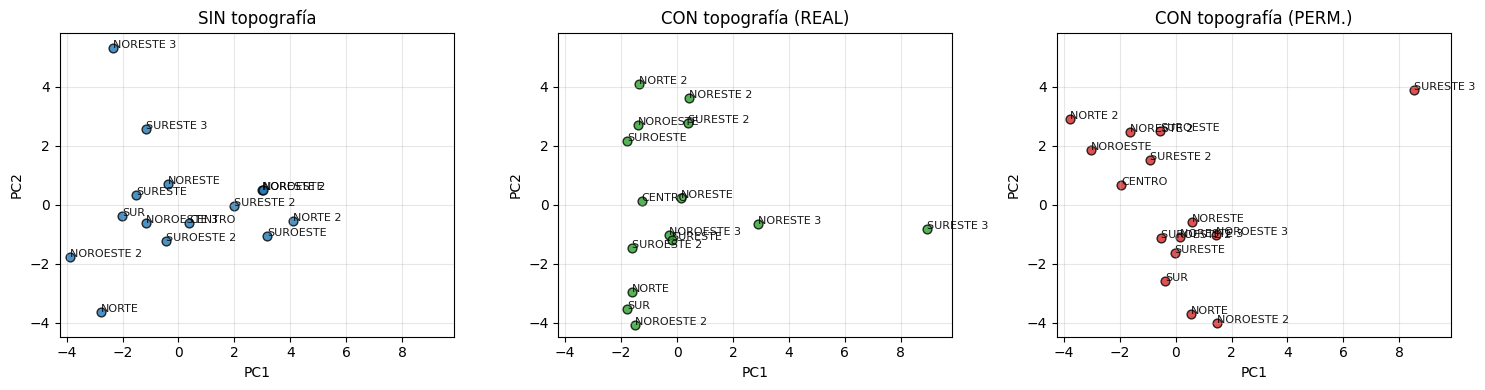

CSV guardados: scores_PC12_*.csv, cargas_CON_topografia_PERMUTADA.csv


In [18]:
#@title #5.b) Control negativo (permuta topografía entre estaciones) + gráficos PC1–PC2 + Procrustes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import procrustes

# 1) Construir topografía PERMUTADA (rompe la relación estación↔topo, conserva valores)
rng = 42  # semilla reproducible
stations = tab_meteo_aligned.index

topo_vals = tab_topo.loc[stations].copy()                     # valores topográficos alineados a estaciones del PCA
topo_perm_vals = topo_vals.sample(frac=1.0, random_state=rng) # baraja filas (valores) entre estaciones
topo_perm_vals = topo_perm_vals.reset_index(drop=True)
topo_perm = topo_perm_vals.set_index(stations)                # re-asigna valores barajados a las MISMAS etiquetas de estación

# Chequeo: ¿cuántas estaciones conservaron EXACTAMENTE su fila topográfica original? (idealmente 0)
same_rows = (topo_vals.reset_index(drop=True).values == topo_perm.reset_index(drop=True).values).all(axis=1).sum()
print(f"Estaciones con topografía idéntica tras permutación (esperado 0): {same_rows}/{len(stations)}")

# 2) Matriz CON topo permutada y PCA
tab_con_perm = tab_meteo_aligned.join(topo_perm, how="inner")
pca_perm, sc_perm, ld_perm = run_pca(tab_con_perm, ncomp=4, title="CON topografía (PERMUTADA)")

print_top_loads(ld_perm, k=8, label="(CON topo PERMUTADA)")

# 3) Scores PC1–PC2 para los tres escenarios
S_no  = get_scores(pca_no,  sc_no,  tab_meteo_aligned)  # SIN topo
S_co  = get_scores(pca_co,  sc_co,  tab_con_perm.drop(columns=topo_perm.columns, errors="ignore").join(tab_topo.loc[stations], how="inner"))  # CON topo REAL
S_prm = get_scores(pca_perm, sc_perm, tab_con_perm)     # CON topo PERMUTADA

# 4) Distancias Procrustes para comparar geometrías del plano PC1–PC2
#    (a) SIN topo vs CON topo REAL
_, _, d_no_vs_co = procrustes(S_no, S_co)
#    (b) SIN topo vs CON topo PERMUTADA (debe ser mayor o, al menos, no menor que en el caso real si la topo aporta señal)
_, _, d_no_vs_prm = procrustes(S_no, S_prm)
#    (c) CON topo REAL vs CON topo PERMUTADA (sirve como control adicional)
_, _, d_co_vs_prm = procrustes(S_co, S_prm)

print(f"\nDistancia Procrustes (PC1–PC2):")
print(f"  SIN vs CON (REAL):      {d_no_vs_co:.3f}")
print(f"  SIN vs CON (PERM.):     {d_no_vs_prm:.3f}")
print(f"  CON (REAL) vs PERM.:    {d_co_vs_prm:.3f}")

# 5) Gráficos PC1–PC2 para anexo (tres paneles)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def plot_scores(ax, scores, title, color, labels):
    ax.scatter(scores[:,0], scores[:,1], s=40, alpha=0.8, c=color, edgecolor="k")
    for i, txt in enumerate(labels):
        ax.annotate(txt, (scores[i,0], scores[i,1]), fontsize=8, alpha=0.9)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title)
    ax.grid(True, alpha=0.3)

# Asegurar mismos límites de ejes para comparación visual
all_scores = np.vstack([S_no, S_co, S_prm])
xlim = (all_scores[:,0].min()*1.1, all_scores[:,0].max()*1.1)
ylim = (all_scores[:,1].min()*1.1, all_scores[:,1].max()*1.1)

labels = list(stations)

plot_scores(axes[0], S_no,  "SIN topografía",          color="#1f77b4", labels=labels)
plot_scores(axes[1], S_co,  "CON topografía (REAL)",   color="#2ca02c", labels=labels)
plot_scores(axes[2], S_prm, "CON topografía (PERM.)",  color="#d62728", labels=labels)

for ax in axes:
    ax.set_xlim(xlim); ax.set_ylim(ylim)

plt.tight_layout()
plt.show()

# 6) (Opcional) Guardar cargas y scores en CSV para anexo
pd.DataFrame(S_no, index=stations, columns=["PC1","PC2"]).to_csv("scores_PC12_SIN_topo.csv")
pd.DataFrame(S_co, index=stations, columns=["PC1","PC2"]).to_csv("scores_PC12_CON_topo_REAL.csv")
pd.DataFrame(S_prm, index=stations, columns=["PC1","PC2"]).to_csv("scores_PC12_CON_topo_PERM.csv")
ld_perm.to_csv("cargas_CON_topografia_PERMUTADA.csv")
print("CSV guardados: scores_PC12_*.csv, cargas_CON_topografia_PERMUTADA.csv")


Cobertura clasificación → estaciones: 15/15 asignadas

Resumen por clase (PC1–PC2) — SIN topo
          PC1                         PC2                     
         mean    std    min    max   mean    std    min    max
clase                                                         
ladera  0.435  2.599 -2.773  4.109  0.632  2.398 -3.657  5.306
valle  -0.652  2.376 -3.860  3.179 -0.948  0.519 -1.789 -0.376

Resumen por clase (PC1–PC2) — CON topo
          PC1                         PC2                     
         mean    std    min    max   mean    std    min    max
clase                                                         
ladera  0.914  3.311 -1.608  8.948  0.867  2.492 -2.974  4.105
valle  -1.371  0.567 -1.791 -0.284 -1.300  2.318 -4.073  2.179


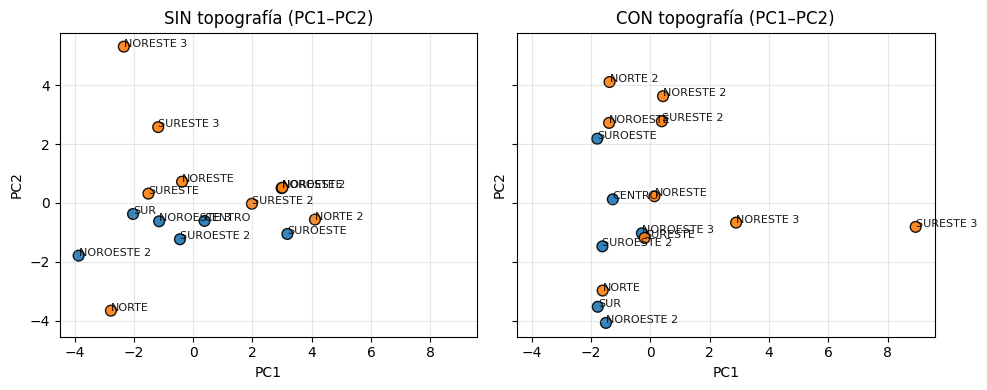


Welch t-tests (SIN topo)
SIN topo — PC1: t=-0.836, p=0.4201 (n_valle=6, n_ladera=9)
SIN topo — PC2: t=-1.910, p=0.0881 (n_valle=6, n_ladera=9)

Welch t-tests (CON topo)
CON topo — PC1: t=-2.026, p=0.0745 (n_valle=6, n_ladera=9)
CON topo — PC2: t=-1.720, p=0.1123 (n_valle=6, n_ladera=9)

PERMANOVA (solo meteo/contaminantes): F=1.279, p=0.2408
PERMANOVA (meteo + topografía):        F=2.023, p=0.0166

CSV guardados: PC12_SINtopo_por_clase.csv, PC12_CONtopo_por_clase.csv


In [19]:
# === 5.c) Clasificación valle/ladera + PCA por clase + pruebas B y C ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.stats import ttest_ind

# --------- 0) Mapeo CLARO de estaciones → clase (15/15) ----------
# USA las claves tal como aparecen en tab_meteo_aligned.index
CLASES = {
    "CENTRO":     "valle",
    "NORESTE":    "ladera",
    "NORESTE 2":  "ladera",
    "NORESTE 3":  "ladera",
    "NOROESTE":   "ladera",
    "NOROESTE 2": "valle",
    "NOROESTE 3": "valle",
    "NORTE":      "ladera",
    "NORTE 2":    "ladera",
    "SUR":        "valle",
    "SURESTE":    "ladera",
    "SURESTE 2":  "ladera",
    "SURESTE 3":  "ladera",
    "SUROESTE":   "valle",
    "SUROESTE 2": "valle",
}

# Chequeo inmediato de cobertura
stations = list(tab_meteo_aligned.index)
missing = sorted(set(stations) - set(CLASES.keys()))
extra   = sorted(set(CLASES.keys()) - set(stations))
print("Cobertura clasificación → estaciones:",
      f"{len(stations)-len(missing)}/{len(stations)} asignadas")
if missing:
    print("⚠ Faltan en CLASES:", missing)
if extra:
    print("ℹ Claves en CLASES que no están en tus datos:", extra)

# Serie de clase alineada al orden de estaciones del PCA
clase = pd.Series({st: CLASES[st] for st in stations}, name="clasificacion")

# --------- 1) Scores PC1–PC2 (ya tienes pca_no/sc_no y pca_co/sc_co) ----------
# SIN topografía
S_no = get_scores(pca_no, sc_no, tab_meteo_aligned)  # (n_est, 2)
df_no = pd.DataFrame(S_no, index=stations, columns=["PC1","PC2"]).assign(clase=clase.values)

# CON topografía (REAL)
tab_con_real = tab_meteo_aligned.join(tab_topo, how="inner")
S_co = get_scores(pca_co, sc_co, tab_con_real)
df_co = pd.DataFrame(S_co, index=stations, columns=["PC1","PC2"]).assign(clase=clase.values)

print("\nResumen por clase (PC1–PC2) — SIN topo")
print(df_no.groupby("clase")[["PC1","PC2"]].agg(["mean","std","min","max"]).round(3))
print("\nResumen por clase (PC1–PC2) — CON topo")
print(df_co.groupby("clase")[["PC1","PC2"]].agg(["mean","std","min","max"]).round(3))

# --------- 2) Gráfico PC1–PC2 coloreado por clase ----------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

def plot_by_class(ax, df, title):
    colors = df["clase"].map({"valle":"tab:blue", "ladera":"tab:orange"})
    ax.scatter(df["PC1"], df["PC2"], c=colors, s=60, edgecolor="k", alpha=0.9)
    for i, st in enumerate(df.index):
        ax.annotate(st, (df["PC1"].iat[i], df["PC2"].iat[i]), fontsize=8, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.grid(True, alpha=0.3)

plot_by_class(axes[0], df_no, "SIN topografía (PC1–PC2)")
plot_by_class(axes[1], df_co, "CON topografía (PC1–PC2)")
plt.tight_layout(); plt.show()

# --------- 3) t-test de Welch (PC1/PC2 por clase) ----------
def welch_tests(df, label):
    g1 = df[df["clase"]=="valle"]
    g2 = df[df["clase"]=="ladera"]
    for comp in ["PC1","PC2"]:
        t, p = ttest_ind(g1[comp], g2[comp], equal_var=False)
        print(f"{label} — {comp}: t={t:.3f}, p={p:.4f} "
              f"(n_valle={len(g1)}, n_ladera={len(g2)})")

print("\nWelch t-tests (SIN topo)")
welch_tests(df_no, "SIN topo")
print("\nWelch t-tests (CON topo)")
welch_tests(df_co, "CON topo")

# --------- 4) PERMANOVA sencilla (B/C): ¿diferen los perfiles multivariados por clase? ----------
def permanova_euclid(X, groups, perms=4999, seed=1):
    """PERMANOVA sobre X (filas=estaciones, cols=vars) con etiquetas 'groups'."""
    rng = np.random.default_rng(seed)
    Xs = StandardScaler().fit_transform(X)  # estandarizar variables
    labels = pd.Series(groups).astype("category")
    lvls = labels.cat.categories
    N, P = Xs.shape
    k = len(lvls)

    # medias
    mu = Xs.mean(axis=0)
    ss_total = ((Xs - mu)**2).sum()

    ss_within = 0.0
    ns = []
    for lvl in lvls:
        Xi = Xs[labels.values == lvl]
        ns.append(len(Xi))
        mu_i = Xi.mean(axis=0)
        ss_within += ((Xi - mu_i)**2).sum()

    ss_between = ss_total - ss_within
    dfb = k - 1
    dfw = N - k
    F = (ss_between/dfb) / (ss_within/dfw)

    # permutaciones
    cnt = 0
    for _ in range(perms):
        perm = rng.permutation(labels.values)
        ss_w = 0.0
        for lvl in lvls:
            Xi = Xs[perm == lvl]
            mu_i = Xi.mean(axis=0)
            ss_w += ((Xi - mu_i)**2).sum()
        ss_b = ss_total - ss_w
        Fp = (ss_b/dfb) / (ss_w/dfw)
        if Fp >= F - 1e-12:
            cnt += 1
    pval = (cnt + 1) / (perms + 1)
    return F, pval

# PERMANOVA en espacio METEOROLÓGICO (solo contaminantes/meteorología)
F_met, p_met = permanova_euclid(tab_meteo_aligned.values, clase.values, perms=4999, seed=7)
print(f"\nPERMANOVA (solo meteo/contaminantes): F={F_met:.3f}, p={p_met:.4f}")

# PERMANOVA en espacio METEO+TOPO (para ver si la topografía 'explica' más)
tab_con_full = tab_meteo_aligned.join(tab_topo, how="inner")
F_full, p_full = permanova_euclid(tab_con_full.values, clase.values, perms=4999, seed=7)
print(f"PERMANOVA (meteo + topografía):        F={F_full:.3f}, p={p_full:.4f}")

# (Opcional) guardar anexo
df_no.to_csv("PC12_SINtopo_por_clase.csv")
df_co.to_csv("PC12_CONtopo_por_clase.csv")
print("\nCSV guardados: PC12_SINtopo_por_clase.csv, PC12_CONtopo_por_clase.csv")


# 6) Regresión por estación y pooled — topografía como modulador de sensibilidad meteo (valle vs. ladera)

In [20]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

METEO_XLSX = "datos_final.xlsx"
SHEET = "Sheet1"
ESTACION_FOCAL = "sur"
METEO_VARS = ["TOUT", "RH", "SR", "WSR"]

CLASIFICACION = {
    "centro":   "valle",
    "noreste2": "ladera",
    "noreste":  "ladera",
    "noreste3": "ladera",
    "noroeste2":"valle",
    "noroeste3":"valle",
    "noroeste": "ladera",
    "norte":    "ladera",
    "norte2":   "ladera",
    "sur":      "valle",
    "sureste2": "ladera",
    "sureste":  "ladera",
    "sureste3": "ladera",
    "suroeste": "valle",
    "suroeste2":"valle",
}

def tidy_from_wide(df_wide: pd.DataFrame) -> pd.DataFrame:
    if "date" not in df_wide.columns:
        raise ValueError("No encontré la columna 'date' en el Excel.")

    df = df_wide.copy().rename(columns={"date": "fecha"})
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    value_cols = [c for c in df.columns if c != "fecha" and "_" in c]
    if not value_cols:
        raise ValueError("No encontré columnas con patrón '<estacion>_<variable>'.")

    multi = pd.MultiIndex.from_tuples([tuple(c.split("_", 1)) for c in value_cols],
                                      names=["estacion", "variable"])
    W = df[value_cols].copy()
    W.columns = multi
    W.index = df["fecha"]

    long_df = W.stack(["estacion","variable"]).reset_index(name="valor")
    tidy = long_df.pivot_table(index=["fecha","estacion"], columns="variable",
                               values="valor", aggfunc="first").reset_index()

    if "WSR" not in tidy.columns and "U" in tidy.columns and "V" in tidy.columns:
        tidy["WSR"] = np.sqrt(pd.to_numeric(tidy["U"], errors="coerce")**2 +
                              pd.to_numeric(tidy["V"], errors="coerce")**2)

    for c in ["PM2.5", "TOUT", "RH", "SR", "WSR"]:
        if c in tidy.columns:
            tidy[c] = pd.to_numeric(tidy[c], errors="coerce")

    tidy["estacion"] = tidy["estacion"].astype(str).str.strip().str.lower()
    return tidy

def q(col: str) -> str:
    return f"Q('{col}')" if (("." in col) or (" " in col)) else col

df_wide = pd.read_excel(METEO_XLSX, sheet_name=SHEET)
tidy = tidy_from_wide(df_wide)
tidy["clasificacion"] = tidy["estacion"].map(CLASIFICACION)

def run_station_ols(tidy_df: pd.DataFrame, station_key: str,
                    y: str = "PM2.5", x_list = METEO_VARS):
    sub = tidy_df[tidy_df["estacion"] == station_key].copy()
    xs = [x for x in x_list if x in sub.columns]
    need = [y] + xs
    sub = sub[need].dropna()
    if len(sub) < 50:
        raise ValueError(f"La estación '{station_key}' no tiene suficientes filas tras limpieza.")

    formula = f"{q(y)} ~ " + " + ".join(q(x) for x in xs)
    model = smf.ols(formula, data=sub).fit()
    return model, formula, len(sub), xs

print("Estaciones disponibles en el Excel:", sorted(tidy["estacion"].unique()))
print("Clasificación (hard-coded) mapeada a cada estación:", {k: CLASIFICACION.get(k) for k in sorted(tidy["estacion"].unique())})

m_sur, f_sur, n_sur, used_x = run_station_ols(tidy, ESTACION_FOCAL)
print("\n=== OLS temporal por estación ===")
print("Estación:", ESTACION_FOCAL)
print("Fórmula:", f_sur)
print(f"Filas usadas: {n_sur}  |  X usadas: {used_x}")
print(m_sur.summary())

present_x = [x for x in METEO_VARS if x in tidy.columns]
pool_cols = ["fecha","estacion","clasificacion","PM2.5"] + present_x
pool = tidy[pool_cols].dropna(subset=["PM2.5"]).copy()
xmask = pool[present_x].notna().sum(axis=1) >= max(1, min(2, len(present_x)))
pool = pool.loc[xmask].copy()
pool = pool[pool["clasificacion"].notna()].copy()

classes = sorted(pool["clasificacion"].astype(str).str.lower().unique())
print("\nPooled — filas:", len(pool), "| estaciones:", pool["estacion"].nunique(), "| clases:", classes)

if len(pool) >= 50 and set(["valle","ladera"]).issubset(classes):
    rhs = " + ".join(q(x) for x in present_x)
    f1 = f"{q('PM2.5')} ~ {rhs}"
    f2 = f1 + " + C(clasificacion)"
    f3 = f1 + " + " + " + ".join([f"{q(x)}:C(clasificacion)" for x in present_x])

    m1 = smf.ols(f1, data=pool).fit()
    m2 = smf.ols(f2, data=pool).fit()
    m3 = smf.ols(f3, data=pool).fit()

    print("\n=== Pooled M1 (solo meteo) ===")
    print(m1.summary())
    print("\n=== Pooled M2 (+ C(clasificacion)) ===")
    print(m2.summary())
    print("\n=== Pooled M3 (+ interacciones meteo×clasificacion) ===")
    print(m3.summary())
else:
    print("Pooled no corrido (pocas filas o no están ambas clases valle/ladera con el diccionario).")


Estaciones disponibles en el Excel: ['centro', 'noreste', 'noreste2', 'noreste3', 'noroeste', 'noroeste2', 'noroeste3', 'norte', 'norte2', 'sur', 'sureste', 'sureste2', 'sureste3', 'suroeste', 'suroeste2']
Clasificación (hard-coded) mapeada a cada estación: {'centro': 'valle', 'noreste': 'ladera', 'noreste2': 'ladera', 'noreste3': 'ladera', 'noroeste': 'ladera', 'noroeste2': 'valle', 'noroeste3': 'valle', 'norte': 'ladera', 'norte2': 'ladera', 'sur': 'valle', 'sureste': 'ladera', 'sureste2': 'ladera', 'sureste3': 'ladera', 'suroeste': 'valle', 'suroeste2': 'valle'}

=== OLS temporal por estación ===
Estación: sur
Fórmula: Q('PM2.5') ~ TOUT + RH + SR + WSR
Filas usadas: 13158  |  X usadas: ['TOUT', 'RH', 'SR', 'WSR']
                            OLS Regression Results                            
Dep. Variable:             Q('PM2.5')   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares

                            OLS Regression Results                            
Dep. Variable:             Q('PM2.5')   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     769.2
Date:                Fri, 05 Sep 2025   Prob (F-statistic):               0.00
Time:                        05:54:49   Log-Likelihood:            -7.0826e+05
No. Observations:              166529   AIC:                         1.417e+06
Df Residuals:                  166519   BIC:                         1.417e+06
Df Model:                           9                                         
Covariance Type:            nonrobust                                         


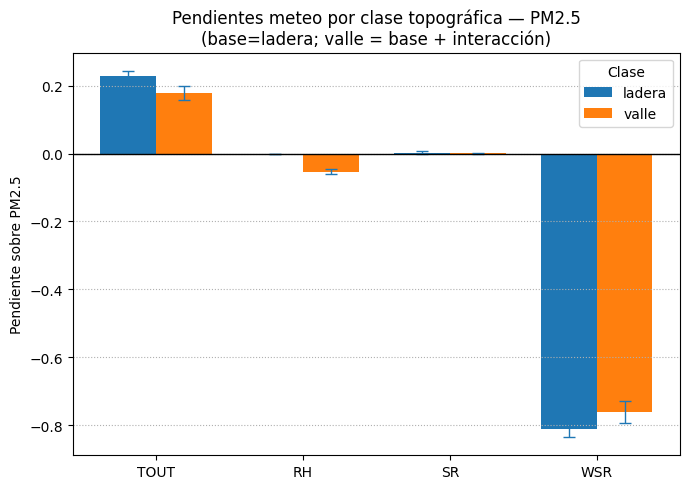

In [22]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

METEO_XLSX = "datos_final.xlsx"
SHEET      = "Sheet1"
TARGET_Y   = "PM2.5"
METEO_VARS = ["TOUT","RH","SR","WSR"]
CLASIFICACION = {
    "centro":"valle","noreste2":"ladera","noreste":"ladera","noreste3":"ladera",
    "noroeste2":"valle","noroeste3":"valle","noroeste":"ladera","norte":"ladera",
    "norte2":"ladera","sur":"valle","sureste2":"ladera","sureste":"ladera",
    "sureste3":"ladera","suroeste":"valle","suroeste2":"valle",
}

def tidy_from_wide(df_wide: pd.DataFrame) -> pd.DataFrame:
    if "date" not in df_wide.columns:
        raise ValueError("No encontré la columna 'date' en el Excel.")
    df = df_wide.copy().rename(columns={"date":"fecha"})
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    value_cols = [c for c in df.columns if c != "fecha" and "_" in c]
    if not value_cols:
        raise ValueError("No encontré columnas con patrón '<estacion>_<variable>'.")

    multi = pd.MultiIndex.from_tuples([tuple(c.split("_", 1)) for c in value_cols],
                                      names=["estacion","variable"])
    W = df[value_cols].copy()
    W.columns = multi
    W.index = df["fecha"]

    long_df = W.stack(["estacion","variable"]).reset_index(name="valor")
    tidy = long_df.pivot_table(index=["fecha","estacion"], columns="variable",
                               values="valor", aggfunc="first").reset_index()

    if "WSR" not in tidy.columns and "U" in tidy.columns and "V" in tidy.columns:
        tidy["WSR"] = np.sqrt(pd.to_numeric(tidy["U"], errors="coerce")**2 +
                              pd.to_numeric(tidy["V"], errors="coerce")**2)

    for c in [TARGET_Y, "TOUT","RH","SR","WSR"]:
        if c in tidy.columns:
            tidy[c] = pd.to_numeric(tidy[c], errors="coerce")

    tidy["estacion"] = tidy["estacion"].astype(str).str.strip().str.lower()
    return tidy

def q(col: str) -> str:
    return f"Q('{col}')" if (("." in col) or (" " in col)) else col

df_wide = pd.read_excel(METEO_XLSX, sheet_name=SHEET)
tidy = tidy_from_wide(df_wide)
tidy["clasificacion"] = tidy["estacion"].map(CLASIFICACION)

present_x = [x for x in METEO_VARS if x in tidy.columns]
pool_cols = ["fecha","estacion","clasificacion", TARGET_Y] + present_x
pool = tidy[pool_cols].dropna(subset=[TARGET_Y]).copy()
xmask = pool[present_x].notna().sum(axis=1) >= max(1, min(2, len(present_x)))
pool = pool.loc[xmask]
pool = pool[pool["clasificacion"].notna()].copy()

if pool.empty or len(set(pool["clasificacion"])) < 2:
    raise ValueError("No hay suficientes datos para ambas clases (valle y ladera).")

rhs = " + ".join(q(x) for x in present_x)
inter_terms = " + ".join([f"{q(x)}:C(clasificacion)" for x in present_x])
formula_M3 = f"{q(TARGET_Y)} ~ {rhs} + C(clasificacion) + {inter_terms}"
m3 = smf.ols(formula_M3, data=pool).fit()
print(m3.summary().tables[0])

results = []
cov = m3.cov_params()

for x in present_x:
    base_name = q(x)
    int_name  = f"{q(x)}:C(clasificacion)[T.valle]"
    if base_name not in m3.params.index:
        continue

    beta  = m3.params[base_name]
    se_b  = np.sqrt(cov.loc[base_name, base_name])
    l_lad = beta - 1.96*se_b
    u_lad = beta + 1.96*se_b

    if int_name in m3.params.index:
        gamma = m3.params[int_name]
        var_sum = (cov.loc[base_name, base_name] +
                   cov.loc[int_name, int_name] +
                   2*cov.loc[base_name, int_name])
        se_val = np.sqrt(max(var_sum, 0))
        beta_val = beta + gamma
        l_val = beta_val - 1.96*se_val
        u_val = beta_val + 1.96*se_val
    else:
        beta_val, l_val, u_val = beta, l_lad, u_lad

    results.append({"variable": x,"clase": "ladera","beta": beta,"lo": l_lad,"hi": u_lad})
    results.append({"variable": x,"clase": "valle","beta": beta_val,"lo": l_val,"hi": u_val})

coef_df = pd.DataFrame(results)
order = [v for v in ["TOUT","RH","SR","WSR"] if v in coef_df["variable"].unique()]
coef_df["variable"] = pd.Categorical(coef_df["variable"], categories=order, ordered=True)
coef_df = coef_df.sort_values(["variable","clase"])

fig, ax = plt.subplots(figsize=(7,5))
xpos = np.arange(len(order))
width = 0.38

for i, cls in enumerate(["ladera","valle"]):
    sub = coef_df[coef_df["clase"] == cls]
    means = sub["beta"].values
    los   = sub["lo"].values
    his   = sub["hi"].values
    errs  = np.vstack([means - los, his - means])

    ax.bar(xpos + (i-0.5)*width, means, width=width, label=cls)
    ax.errorbar(xpos + (i-0.5)*width, means, yerr=errs, fmt='none', capsize=4, linewidth=1)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(xpos)
ax.set_xticklabels(order)
ax.set_ylabel(f"Pendiente sobre {TARGET_Y}")
ax.set_title(f"Pendientes meteo por clase topográfica — {TARGET_Y}\n(base=ladera; valle = base + interacción)")
ax.legend(title="Clase")
ax.grid(True, axis="y", linestyle=":", linewidth=0.8)
fig.tight_layout()
plt.show()
